# 04 Simple GAN Experiment: Learning to Generate Real 911-Call Locations

**Unit:** Unit 5: Introduction to Generative AI and Course Summary

**Why this notebook?** In example 02 we saw that a *generative* model learns the data
distribution P(X) itself, while a *discriminative* model only learns the boundary
P(Y|X). That raises an obvious practical question: how do you actually *train* a
network to generate realistic new samples when there is no "correct answer" to
compare each output against? A Generative Adversarial Network (GAN) solves this with
a trick: it uses a **discriminative model as the teacher** for a generative one. Here
we build the smallest GAN that shows the idea working — a generator that learns to
produce 2D points shaped like the **real map of emergency calls** in two Pennsylvania
townships (Norristown and Pottstown) — so you can watch the adversarial game converge in a couple of seconds on a CPU.

The target distribution is **real data**: latitude/longitude of 911 calls logged in
Montgomery County, PA. The two townships sit far apart on the map, so the real
distribution has two genuinely separated clusters — and a generator that only learns one
of them has *mode collapsed*, exactly the failure we want to be able to measure.

## 📚 Learning Objectives

By completing this notebook, you will:
- See why a plain supervised loss (MSE) fails at generation — it collapses to the average
- Build a generator and a discriminator as tiny Keras `Dense` networks
- Train them with a custom adversarial training loop (~2000 steps)
- Read GAN loss curves and understand why neither loss goes to zero
- Check generation quality with simple honest metrics (nearest-neighbour distances, mode coverage)

## 🔗 Prerequisites

- ✅ Example 02 (generative vs discriminative models)
- ✅ Basic Keras: `Dense` layers, optimizers, loss functions
- ✅ Basic NumPy and Matplotlib

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- A **real** 2D dataset: 2,000 sampled 911-call coordinates (lat/lng) from two Montgomery County
  townships, read from `Course 04/datasets/raw/montgomery_911_calls.csv`
- TensorFlow/Keras for the generator, discriminator, and custom training loop

**Outputs:** What you'll see when you run the cells

- A scatter plot of the real call-location distribution
- A baseline experiment: an MSE-trained generator that collapses to the data mean
- Training progress lines every 250 steps (losses + distance metrics)
- A final figure: a 3×3 grid of snapshots showing generated points converging onto
  the real distribution, plus the generator/discriminator loss curves
- A printed side-by-side comparison table: MSE baseline vs adversarial training

---

TensorFlow: 2.21.0 | Keras: 3.15.1
Full dispatch log: 663,522 real emergency calls


Dropped 2 rows with out-of-county coordinates (real data-entry errors)

Real dataset: 2000 calls, 2 features (lng, lat) — sampled from 65,018 calls with random_state=42
  NORRISTOWN    : 1146 calls (57.3% of the sample)
  POTTSTOWN     :  854 calls (42.7% of the sample)
Per-axis mean: [ 0. -0.] | per-axis std: [1. 1.]


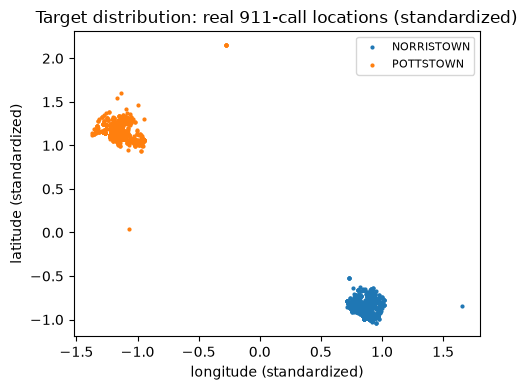

In [1]:
# GAN experiment setup: the generator must learn to produce points shaped like the REAL
# map of 911 calls in two townships. 2D data keeps everything visible — you can SEE the
# distribution being learned, and you can see if a whole township goes missing.
"""
Unit 5 - Example 4: Simple GAN Experiment (real 911-call locations)

Setup: imports, seeds, and the real target distribution the generator must learn.
"""

import time
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

t_start = time.time()
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)

SEED = 42
keras.utils.set_random_seed(SEED)  # seeds Python, NumPy and TensorFlow

# ---- REAL DATA ----
# Montgomery County (PA) 911 dispatch log. usecols keeps only the three columns we need
# so the 123 MB file loads in about a second.
CSV = "../../../Course 04/datasets/raw/montgomery_911_calls.csv"
calls = pd.read_csv(CSV, usecols=["lat", "lng", "twp"])
print(f"Full dispatch log: {len(calls):,} real emergency calls")

# Two townships that sit far apart on the map. Their calls form two clearly separated
# real clusters — our stand-in for "two modes" that the generator must both cover.
TOWNSHIPS = ["NORRISTOWN", "POTTSTOWN"]
calls = calls[calls["twp"].isin(TOWNSHIPS)].dropna(subset=["lat", "lng"])

# Real data has real errors: a handful of rows carry coordinates from other states
# (typos in the dispatch system). Clip to the county bounding box and say how many we drop.
in_county = calls["lat"].between(39.9, 40.5) & calls["lng"].between(-75.8, -74.9)
print(f"Dropped {(~in_county).sum()} rows with out-of-county coordinates (real data-entry errors)")
calls = calls[in_county]

# Classroom-size the data honestly: a 2,000-call random sample, random_state=42.
N_REAL = 2000
sample = calls.sample(n=N_REAL, random_state=42)
X_raw = sample[["lng", "lat"]].to_numpy()          # x = longitude, y = latitude
y_town = (sample["twp"] == TOWNSHIPS[0]).to_numpy().astype(int)   # 1 = Norristown

print(f"\nReal dataset: {X_raw.shape[0]} calls, {X_raw.shape[1]} features "
      f"(lng, lat) — sampled from {len(calls):,} calls with random_state=42")
for i, name in enumerate(TOWNSHIPS):
    n = int((y_town == (1 - i)).sum())
    print(f"  {name:<14}: {n:4d} calls ({n / N_REAL:.1%} of the sample)")

# Standardize to zero mean / unit std so both networks see well-scaled inputs.
X_real = ((X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)).astype("float32")
print("Per-axis mean:", X_real.mean(axis=0).round(3), "| per-axis std:", X_real.std(axis=0).round(3))

REAL_BALANCE = float(y_town.mean())   # the real proportion the generator should match

plt.figure(figsize=(5, 4))
for i, name in enumerate(TOWNSHIPS):
    m = y_town == (1 - i)
    plt.scatter(X_real[m, 0], X_real[m, 1], s=4, label=name)
plt.title("Target distribution: real 911-call locations (standardized)")
plt.xlabel("longitude (standardized)"); plt.ylabel("latitude (standardized)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Honest measurement first

"The samples look right" is not a measurement. Before training anything we define
three cheap, printable metrics and use them for **every** experiment below:

- **gen→real distance** — average distance from each generated point to its nearest
  real point. Small = generated points sit *on* the data manifold (quality).
- **real→gen distance** — average distance from each real point to its nearest
  generated point. Small = the generator *covers* the whole distribution
  (this is the one that catches **mode collapse**: if the generator only produces
  calls from one township, real→gen stays large even when gen→real is small).
- **mode balance** — fraction of generated points whose nearest real neighbour is a
  **Norristown** call. Note the target here is *not* 0.50: the real sample is
  genuinely imbalanced, so a generator that covers the distribution faithfully should
  land near the real proportion printed above. Real data does not come in equal halves,
  and neither should a generator's output.

In [2]:
# Measurement tools and model builders. The three metrics (spread, two-way nearest-
# neighbour distance, mode balance) will tell us objectively whether generated points
# cover BOTH townships, or quietly abandon one of them.
def nn_dist(A, B):
    """Average over rows of A of the distance to the nearest row of B."""
    d = np.sqrt(((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=-1))
    return float(d.min(axis=1).mean())


def mode_balance(points):
    """Fraction of points whose nearest real neighbour is a Norristown call."""
    d = np.sqrt(((points[:, None, :] - X_real[None, :, :]) ** 2).sum(axis=-1))
    return float(y_town[d.argmin(axis=1)].mean())


def report(name, points):
    print(f"{name:<22} per-axis std {points.std(axis=0).round(2)}  "
          f"gen->real {nn_dist(points, X_real):.3f}  "
          f"real->gen {nn_dist(X_real, points):.3f}  "
          f"mode balance {mode_balance(points):.2f}")


LATENT = 8    # generator input: 8D Gaussian noise
HIDDEN = 64   # width of the two small hidden Dense layers in each network
BATCH = 128


def make_generator():
    """Noise z (8D) -> 2D point. Two small hidden Dense layers + linear output."""
    return keras.Sequential([
        layers.Input(shape=(LATENT,)),
        layers.Dense(HIDDEN, activation="relu"),
        layers.Dense(HIDDEN, activation="relu"),
        layers.Dense(2),
    ], name="generator")


# Sanity check the metrics on the real data itself: distances ~0, and a balance equal
# to the real township proportion (NOT 0.50 — this dataset is genuinely imbalanced).
report("real data vs itself", X_real)
print(f"Real Norristown share (the number a faithful generator should match): {REAL_BALANCE:.2f}")

real data vs itself    per-axis std [1. 1.]  gen->real 0.000  real->gen 0.000  mode balance 0.57
Real Norristown share (the number a faithful generator should match): 0.57


## Baseline: the obvious idea, and why it fails

The obvious way to train a generator is supervised learning: sample noise `z`, pick a
random real point as the "target", and minimize the MSE between them. Every tool we
need is familiar from earlier units.

But think about what that loss asks for. Each noise vector gets paired with a
*different random* real point every step, so the best a deterministic network can do
is output something close to **all** targets at once — the **average** of the data.
The loss cannot reward variety; it rewards playing it safe. Let's confirm that
prediction by running it.

MSE baseline: 1000 steps in 0.5s, final MSE loss 0.997
MSE generator          per-axis std [0.05 0.05]  gen->real 0.897  real->gen 1.216  mode balance 0.95
real data vs itself    per-axis std [1. 1.]  gen->real 0.000  real->gen 0.000  mode balance 0.57


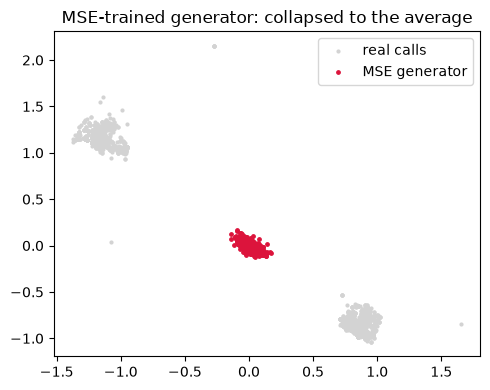

In [3]:
# Baseline WITHOUT an adversary: train the generator by MSE against randomly paired
# real points. It collapses to the average — the failure that motivates the discriminator.
g_mse = make_generator()
mse_opt = keras.optimizers.Adam(1e-3)
rng = np.random.default_rng(SEED)


@tf.function
def mse_step(z, x_target):
    with tf.GradientTape() as tape:
        fake = g_mse(z, training=True)
        loss = tf.reduce_mean(tf.square(fake - x_target))
    grads = tape.gradient(loss, g_mse.trainable_variables)
    mse_opt.apply_gradients(zip(grads, g_mse.trainable_variables))
    return loss

t0 = time.time()
for step in range(1000):
    z = tf.random.normal((BATCH, LATENT))
    x_target = X_real[rng.integers(0, N_REAL, BATCH)]  # random pairing
    loss = mse_step(z, x_target)
print(f"MSE baseline: 1000 steps in {time.time() - t0:.1f}s, final MSE loss {float(loss):.3f}")

z_eval = tf.random.normal((500, LATENT), seed=7)
mse_points = g_mse(z_eval, training=False).numpy()
report("MSE generator", mse_points)
report("real data vs itself", X_real)

plt.figure(figsize=(5, 4))
plt.scatter(X_real[:, 0], X_real[:, 1], s=4, c="lightgray", label="real calls")
plt.scatter(mse_points[:, 0], mse_points[:, 1], s=6, c="crimson", label="MSE generator")
plt.title("MSE-trained generator: collapsed to the average")
plt.legend(); plt.tight_layout(); plt.show()

**Baseline conclusion (matches the printout above):** the MSE generator's per-axis
std is 0.05 vs 1.0 for the real data, and the real→gen distance is large (1.216) —
every real call location is far from the nearest generated one. The samples are a tiny
blob near the data mean, sitting in empty countryside between the two towns: technically
low loss, useless as generation.

## Change one thing: replace the fixed target with a learned judge

Keep the *exact same generator architecture*. The one thing we change is the training
signal: instead of "match this random point", the generator is scored by a second
network — a **discriminator** — that is itself being trained to tell real points from
generated ones. This is the adversarial game:

- The **discriminator** (a plain binary classifier, exactly the discriminative
  P(real | x) model from example 02) is trained to output "real" on data points and
  "fake" on generator outputs.
- The **generator** never sees real data directly. Its loss is simply "make the
  discriminator say *real*", and its gradients flow *through* the discriminator.

Counterfeiter vs. detective: as the detective gets sharper, the only way for the
counterfeiter to keep winning is to produce points that lie on the true distribution
— *everywhere* on it, because any under-covered region is an easy tell. Abandoning
Pottstown entirely would be the easiest tell of all. That pressure toward variety is
exactly what MSE lacked.

Two standard stability tricks, honestly declared: `Adam(beta_1=0.5)` for both
networks, and label smoothing (real labels = 0.9) for the discriminator.

In [4]:
# The real GAN: discriminator learns to tell real from fake while the generator learns
# to fool it — a two-player game where each step trains both networks in turn.
# Fresh seeds so this experiment does not depend on how many random draws
# the baseline consumed above.
keras.utils.set_random_seed(SEED)
rng_gan = np.random.default_rng(SEED)

generator = make_generator()
discriminator = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(HIDDEN, activation=layers.LeakyReLU(0.2)),
    layers.Dense(HIDDEN, activation=layers.LeakyReLU(0.2)),
    layers.Dense(1),  # logit: >0 means "looks real"
], name="discriminator")
print(f"generator params: {generator.count_params():,} | "
      f"discriminator params: {discriminator.count_params():,}")

g_opt = keras.optimizers.Adam(1e-3, beta_1=0.5)
d_opt = keras.optimizers.Adam(1e-3, beta_1=0.5)
bce = keras.losses.BinaryCrossentropy(from_logits=True)


@tf.function
def gan_step(x_real_batch):
    # --- 1) discriminator step: real -> 0.9 (label smoothing), fake -> 0
    z = tf.random.normal((BATCH, LATENT))
    with tf.GradientTape() as tape:
        fake = generator(z, training=True)
        real_logits = discriminator(x_real_batch, training=True)
        fake_logits = discriminator(fake, training=True)
        d_loss = (bce(tf.ones_like(real_logits) * 0.9, real_logits)
                  + bce(tf.zeros_like(fake_logits), fake_logits))
    d_grads = tape.gradient(d_loss, discriminator.trainable_variables)
    d_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    # --- 2) generator step: make the discriminator output "real" on fakes
    z = tf.random.normal((BATCH, LATENT))
    with tf.GradientTape() as tape:
        fake = generator(z, training=True)
        fake_logits = discriminator(fake, training=True)
        g_loss = bce(tf.ones_like(fake_logits), fake_logits)
    g_grads = tape.gradient(g_loss, generator.trainable_variables)
    g_opt.apply_gradients(zip(g_grads, generator.trainable_variables))
    return d_loss, g_loss


# The training loop: snapshot the generator's output every 250 steps so we can watch
# the two real township clusters form.
STEPS = 2000
SNAP_EVERY = 250
z_vis = tf.random.normal((500, LATENT), seed=7)  # fixed noise for all snapshots

d_hist, g_hist, snapshots = [], [], {}
t0 = time.time()
for step in range(STEPS + 1):
    if step % SNAP_EVERY == 0:
        pts = generator(z_vis, training=False).numpy()
        snapshots[step] = pts
        d_str = f"{d_hist[-1]:.3f}" if d_hist else "  -  "
        g_str = f"{g_hist[-1]:.3f}" if g_hist else "  -  "
        print(f"step {step:4d} | d_loss {d_str} g_loss {g_str} | "
              f"gen->real {nn_dist(pts, X_real):.3f}  real->gen {nn_dist(X_real, pts):.3f}  "
              f"balance {mode_balance(pts):.2f}")
    if step < STEPS:
        d_loss, g_loss = gan_step(X_real[rng_gan.integers(0, N_REAL, BATCH)])
        d_hist.append(float(d_loss)); g_hist.append(float(g_loss))

print(f"Adversarial training: {STEPS} steps in {time.time() - t0:.1f}s")

generator params: 4,866 | discriminator params: 4,417
step    0 | d_loss   -   g_loss   -   | gen->real 0.696  real->gen 1.033  balance 0.06


step  250 | d_loss 1.331 g_loss 0.879 | gen->real 0.515  real->gen 0.035  balance 0.60
step  500 | d_loss 1.270 g_loss 1.023 | gen->real 0.108  real->gen 0.025  balance 0.70
step  750 | d_loss 1.313 g_loss 0.879 | gen->real 0.045  real->gen 0.020  balance 0.63


step 1000 | d_loss 1.357 g_loss 0.942 | gen->real 0.034  real->gen 0.027  balance 0.56
step 1250 | d_loss 1.379 g_loss 0.847 | gen->real 0.030  real->gen 0.029  balance 0.57
step 1500 | d_loss 1.361 g_loss 0.955 | gen->real 0.019  real->gen 0.025  balance 0.56


step 1750 | d_loss 1.355 g_loss 0.802 | gen->real 0.022  real->gen 0.032  balance 0.54
step 2000 | d_loss 1.394 g_loss 0.838 | gen->real 0.018  real->gen 0.034  balance 0.55
Adversarial training: 2000 steps in 1.0s


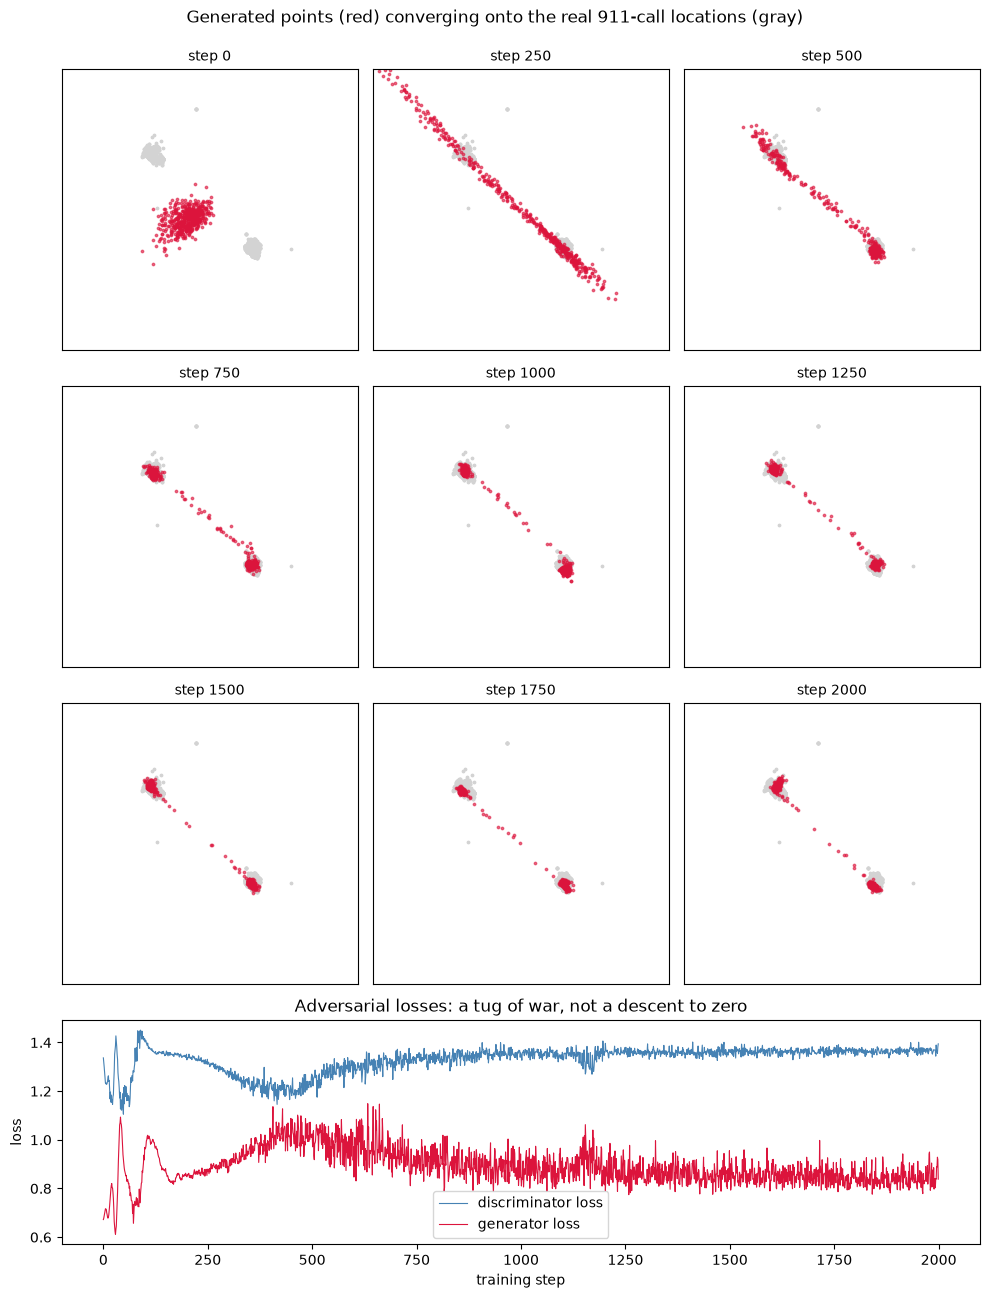

Mean d_loss over last 500 steps: 1.364
Mean g_loss over last 500 steps: 0.849


In [5]:
# The payoff picture: nine snapshots of generated points converging onto the real call
# map, plus the loss curves — note they oscillate in balance rather than dropping to zero.
# Final figure: 3x3 grid of snapshots (top) + the two loss curves (bottom).
fig = plt.figure(figsize=(10, 13))
gs = fig.add_gridspec(4, 3, height_ratios=[1, 1, 1, 0.8])

for i, (step, pts) in enumerate(snapshots.items()):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.scatter(X_real[:, 0], X_real[:, 1], s=3, c="lightgray")
    ax.scatter(pts[:, 0], pts[:, 1], s=3, c="crimson", alpha=0.6)
    ax.set_title(f"step {step}", fontsize=10)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_xticks([]); ax.set_yticks([])

ax = fig.add_subplot(gs[3, :])
ax.plot(d_hist, label="discriminator loss", color="steelblue", linewidth=0.8)
ax.plot(g_hist, label="generator loss", color="crimson", linewidth=0.8)
ax.set_xlabel("training step"); ax.set_ylabel("loss")
ax.set_title("Adversarial losses: a tug of war, not a descent to zero")
ax.legend()

fig.suptitle("Generated points (red) converging onto the real 911-call locations (gray)",
             y=0.995)
plt.tight_layout()
plt.show()

print(f"Mean d_loss over last 500 steps: {np.mean(d_hist[-500:]):.3f}")
print(f"Mean g_loss over last 500 steps: {np.mean(g_hist[-500:]):.3f}")

In [6]:
# Side-by-side comparison: same generator architecture, different training signal.
gan_points = snapshots[STEPS]

print("Same generator architecture, one change (the training signal):\n")
report("real data (reference)", X_real)
report("MSE baseline", mse_points)
report("GAN, step 0", snapshots[0])
report(f"GAN, step {STEPS}", gan_points)

print(f"\nTotal notebook runtime so far: {time.time() - t_start:.1f}s")

Same generator architecture, one change (the training signal):

real data (reference)  per-axis std [1. 1.]  gen->real 0.000  real->gen 0.000  mode balance 0.57
MSE baseline           per-axis std [0.05 0.05]  gen->real 0.897  real->gen 1.216  mode balance 0.95
GAN, step 0            per-axis std [0.25 0.22]  gen->real 0.696  real->gen 1.033  mode balance 0.06
GAN, step 2000         per-axis std [0.96 1.04]  gen->real 0.018  real->gen 0.034  mode balance 0.55

Total notebook runtime so far: 2.1s


## What the outputs show

Reading the comparison table and the figure together (all numbers are printed above):

1. **MSE collapses, the GAN does not.** The MSE generator's per-axis std is 0.05 and
   its real→gen distance is 1.216 — a blob at the mean. After 2000 adversarial steps
   the generator's per-axis std is 0.96 / 1.04 (matching the real data) and real→gen
   drops to 0.034: essentially every real call location now has a generated point right
   next to it. Same architecture — the *only* change was who provides the training signal.
2. **The snapshots tell the convergence story.** Step 0 is an untrained blob sitting
   almost entirely over Pottstown (balance 0.06); the middle panels wander and overshoot
   while the two networks push each other around; by steps 1500–2000 the red points
   visibly fill both real town footprints.
3. **Both towns are covered.** Mode balance ends at 0.55 against a real Norristown share
   of 0.57 — the generator matched the *real* imbalance instead of collapsing onto the
   larger town. That is the failure mode the real→gen metric was built to catch, and it
   is a failure this exact code really does produce on other township pairs.
4. **The loss curves are a tug of war.** Neither loss decreases to zero the way a
   classifier's loss did in example 03. They oscillate strongly for the first several
   hundred steps, then settle around an equilibrium (mean over the last 500 steps:
   d_loss 1.364, g_loss 0.849), because each network's improvement *is* the other
   network's loss increase. For GANs, sample quality — not the loss value — is the
   success measure.

## Tie-back to this unit

- Example 02 said: discriminative models learn P(Y|X), generative models learn P(X).
  A GAN is the two ideas welded together — a *discriminative* network (the
  discriminator is literally a binary classifier) is used as a **learned, moving
  loss function** to train a *generative* network.
- The generator never sees a real data point. Everything it knows about where people
  in Montgomery County call 911 arrives as gradients through the discriminator.

## Honest limitations

- The data is real, but the problem is small: two coordinates per sample, both networks
  are two small hidden `Dense` layers, and training takes seconds. Real GANs (images,
  audio) need convolutional architectures, far more compute, and much more careful tuning.
- GAN training is famously sensitive, and this is not a hypothetical warning: run this
  identical code on the **Lower Merion / Pottstown** pair instead and it mode-collapses
  onto Lower Merion — mode balance 1.00, real→gen 1.03, per-axis std 0.04 / 0.07 — abandoning
  Pottstown completely. Those two towns sit further apart and the split is more lopsided
  (68/32), and a tiny generator takes the easy win. The metrics we printed (real→gen
  distance, mode balance) are exactly the check that catches it; without them the
  scatter plot of Lower Merion alone would look perfectly convincing.
- Modern image generators are mostly diffusion models rather than GANs, but the core
  lesson — train a generator with a learned signal instead of a fixed per-sample
  target — carries over.

## 📚 References

1. Goodfellow, I., Pouget-Abadie, J., Mirza, M., et al. (2014). *Generative Adversarial Nets*. NeurIPS. <https://arxiv.org/abs/1406.2661>
2. Radford, A., Metz, L., & Chintala, S. (2016). *Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks* (DCGAN). ICLR. <https://arxiv.org/abs/1511.06434>
3. Karras, T., Laine, S., Aittala, M., et al. (2020). *Analyzing and Improving the Image Quality of StyleGAN* (StyleGAN2). CVPR. <https://arxiv.org/abs/1912.04958>